# FINAL — Normalizing Flow / RealNVP

Questo notebook implementa il **Normalizing Flow finale** usando i dataset aggregate creati dal preprocessing `FINAL`.

Input previsto:

```text
FINAL/processed/repr1_aggregate.npz
```

Il modello è un **RealNVP stabile** addestrato solo su QCD/background,
impara una trasformazione invertibile che porta i dati reali, in questo caso jet QCD, verso una distribuzione semplice, di solito una gaussiana standard.

L’idea è che i jet QCD, essendo usati per il training, dovrebbero avere alta probabilità secondo il modello. Eventi più strani, come possibili Emerging Jets, dovrebbero invece risultare meno probabili e quindi avere uno score di anomalia più alto.

La versione “stabile” serve soprattutto a evitare problemi numerici durante il training. Per questo si usano accorgimenti come clipping o limitazione dei fattori di scala, normalizzazione delle feature, weight decay e controlli su valori `NaN` o infiniti. In questo modo il flow resta invertibile e la likelihood non esplode numericamente.

In sintesi, il RealNVP stabile viene usato per stimare quanto un evento è compatibile con la distribuzione QCD appresa: più la likelihood è bassa, più l’evento è considerato anomalo.
Schema:

```text
bkg_train  -> training QCD
bkg_eval   -> validation QCD + test QCD interno
sig        -> signal EJ
```


Score di anomalia:

```text
score = NLL = -log p(x)
```

dove `x` è il vettore aggregate jet+track.



## Si tratta di un modello che misura quanto un jet è "probabile"

A differenza di AE e VAE, che misurano un **errore di ricostruzione**, il Normalizing Flow stima direttamente la **probabilità** di ogni jet. Impara una trasformazione *reversibile* che "raddrizza" la complicata distribuzione dei jet QCD trasformandola in una semplice gaussiana. Una volta imparata:

- un jet QCD (tipico) → finisce nella zona densa della gaussiana → **probabilità alta** → NLL basso;
- un Emerging Jet (raro) → finisce in una zona poco popolata → **probabilità bassa** → **NLL alto** = anomalia.

L'anomaly score è quindi la **negative log-likelihood** `NLL = −log p(x)`: più è alta, più il jet è incompatibile con ciò che il modello ha imparato sul QCD.

| Modello | Cosa misura | Anomaly score |
|---|---|---|
| AE / VAE | errore di ricostruzione | MSE / residuo |
| **Normalizing Flow** | **densità di probabilità** | **NLL = −log p(x)** |

### Mappa del notebook
| Sezione | Contenuto |
|---|---|
| 1–3 | Setup, caricamento dati, split QCD train/val/test |
| 4–6 | Anti-leakage, robust scaling, DataLoader |
| 7 | Il modello RealNVP (coupling layer invertibili) |
| 7.1–7.2 | Tuning iperparametri (solo QCD) |
| 8–9 | Training (massima verosimiglianza) e curve |
| 10 | Anomaly score (NLL) |
| 11–12 | Metriche: AUC, efficienza, controlli sul fondo |
| 14 | Salvataggio |

> Nota: train, val e test sono tutti QCD; il segnale EJ entra **solo** nella valutazione finale.


## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e caricamento dataset aggregate

In [2]:
# Funziona sia se il notebook è lanciato da FINAL/notebooks,
# sia se è lanciato dalla root del progetto.

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr1_aggregate.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr1_aggregate.npz. "
        "Controlla che esista in FINAL/processed/repr1_aggregate.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "normalizing_flow"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr1_aggregate.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr1_aggregate.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\normalizing_flow

Keys in repr1_aggregate.npz:
  bkg_train                           shape=(40000, 96) dtype=float32
  bkg_eval                            shape=(40000, 96) dtype=float32
  sig                                 shape=(40000, 96) dtype=float32
  feature_names                       shape=(96,) dtype=object
  norm_mean                           shape=(1, 96) dtype=float32
  norm_std                            shape=(1, 96) dtype=float32


## 3. Caricamento robusto e split QCD train / val / test

Carichiamo i tre blocchi dal file aggregate cercando i nomi-chiave in modo tollerante (così funziona anche con naming diversi). Punto metodologico importante: se nel file **non** c'è un test-background dedicato, qui spezziamo `bkg_eval` **50/50 in validation e test**:
- la **validation** serve per early-stopping e per il tuning (vede QCD durante la selezione del modello);
- il **test** resta *held-out*: lo usiamo **solo** nella ROC finale, mai per scegliere nulla.

Così la valutazione finale avviene su un QCD che il modello non ha mai usato per calibrarsi — la metodologia "pulita" (un test indipendente dalla calibrazione). Il segnale EJ, come sempre, entra solo alla fine.


In [3]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


train_key = first_existing_key(
    data,
    [
        "X_agg_bkg_train",
        "bkg_train",
        "X_bkg_train",
        "X_train_background",
        "X_agg_train_background",
        "train_background",
        "X_train",
    ],
)

eval_key = first_existing_key(
    data,
    [
        "X_agg_bkg_eval",
        "bkg_eval",
        "X_bkg_eval",
        "X_eval_background",
        "X_agg_eval_background",
        "eval_background",
        "X_eval",
        "X_val",
    ],
)

test_bkg_key = first_existing_key(
    data,
    [
        "X_agg_bkg_test",
        "bkg_test",
        "X_bkg_test",
        "X_test_background",
        "X_agg_test_background",
        "test_background",
        "X_test_bkg",
    ],
    required=False,
)

sig_key = first_existing_key(
    data,
    [
        "X_agg_sig",
        "sig",
        "X_sig",
        "X_signal",
        "X_test_signal",
        "X_agg_test_signal",
        "test_signal",
    ],
)

feature_key = first_existing_key(
    data,
    [
        "aggregate_feature_names",
        "agg_feature_names",
        "feature_names",
        "X_agg_feature_names",
    ],
    required=False,
)

X_train_raw = np.asarray(data[train_key], dtype=np.float32)
X_eval_raw = np.asarray(data[eval_key], dtype=np.float32)
X_sig_raw = np.asarray(data[sig_key], dtype=np.float32)

if test_bkg_key is not None:
    X_bkg_test_raw = np.asarray(data[test_bkg_key], dtype=np.float32)
    X_val_raw = X_eval_raw
    print("Uso test background separato:", test_bkg_key)
else:
    X_val_raw, X_bkg_test_raw = train_test_split(
        X_eval_raw,
        test_size=0.5,
        random_state=SEED,
        shuffle=True,
    )
    #print("Nessun test background separato trovato: splitto bkg_eval in val/test 50/50.")

if feature_key is not None:
    aggregate_feature_names = [str(x) for x in data[feature_key].tolist()]
else:
    aggregate_feature_names = [f"f{i}" for i in range(X_train_raw.shape[1])]

print("\nSelected keys:")
print("train:", train_key, X_train_raw.shape)
print("eval:", eval_key, X_eval_raw.shape)
print("val:", X_val_raw.shape)
print("bkg_test:", test_bkg_key, X_bkg_test_raw.shape)
print("signal:", sig_key, X_sig_raw.shape)
print("n features:", len(aggregate_feature_names))


Selected keys:
train: bkg_train (40000, 96)
eval: bkg_eval (40000, 96)
val: (20000, 96)
bkg_test: None (20000, 96)
signal: sig (40000, 96)
n features: 96


## 4. Anti-leakage check

In [4]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in aggregate_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input aggregate:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input aggregate.")

Leakage check OK: nessuna feature vietata trovata negli input aggregate.


## 5. Pulizia, robust scaling e clipping

Prima del flow ripuliamo e riscaliamo le feature. Usiamo uno scaling **robusto** (`RobustClipScaler`): invece di media e deviazione standard (sensibili agli outlier), centriamo sulla **mediana** e dividiamo per l'**IQR** (intervallo interquartile, q75−q25). Mediana e IQR sono poco influenzati dalle code estreme, quindi un singolo valore anomalo non distorce la scala.

Infine **clippiamo** a ±`CLIP_VALUE` (8): i flow sono numericamente delicati (la likelihood passa per `exp(s)` e log-determinanti), e un input enorme può far esplodere la loss. Lo scaler è *fittato solo sul QCD train* e poi applicato a val/test/segnale — nessuna informazione del test o del segnale entra nella calibrazione.


In [5]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_train_raw = finite_array(X_train_raw, "X_train_raw")
X_val_raw = finite_array(X_val_raw, "X_val_raw")
X_bkg_test_raw = finite_array(X_bkg_test_raw, "X_bkg_test_raw")
X_sig_raw = finite_array(X_sig_raw, "X_sig_raw")


class RobustClipScaler:
    def __init__(self, clip_value=8.0, eps=1e-6):
        self.clip_value = clip_value
        self.eps = eps
        self.center = None
        self.scale = None

    def fit(self, X):
        self.center = np.median(X, axis=0, keepdims=True)
        q25 = np.percentile(X, 25, axis=0, keepdims=True)
        q75 = np.percentile(X, 75, axis=0, keepdims=True)
        self.scale = np.maximum(q75 - q25, self.eps)
        return self

    def transform(self, X):
        Xn = (X - self.center) / self.scale
        Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
        Xn = np.clip(Xn, -self.clip_value, self.clip_value)
        return Xn.astype(np.float32)

    def state_dict(self):
        return {
            "clip_value": float(self.clip_value),
            "eps": float(self.eps),
            "center": self.center.reshape(-1).tolist(),
            "scale": self.scale.reshape(-1).tolist(),
        }


CLIP_VALUE = 8.0

scaler = RobustClipScaler(clip_value=CLIP_VALUE)
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_bkg_test = scaler.transform(X_bkg_test_raw)
X_sig = scaler.transform(X_sig_raw)

print("After robust scaling + clipping:")
for name, X in [
    ("train", X_train),
    ("val", X_val),
    ("bkg_test", X_bkg_test),
    ("signal", X_sig),
]:
    print(
        f"{name:10s} shape={X.shape} "
        f"mean={X.mean():.4f} std={X.std():.4f} "
        f"clip_frac={np.mean((X <= -CLIP_VALUE) | (X >= CLIP_VALUE)):.5f}"
    )

input_dim = X_train.shape[1]
print("input_dim:", input_dim)

with open(OUTPUT_DIR / "aggregate_flow_scaler.json", "w") as f:
    json.dump(scaler.state_dict(), f, indent=2)

print("Saved scaler:", OUTPUT_DIR / "aggregate_flow_scaler.json")

After robust scaling + clipping:
train      shape=(40000, 96) mean=0.0187 std=1.1448 clip_frac=0.00941
val        shape=(20000, 96) mean=0.0183 std=1.1440 clip_frac=0.00942
bkg_test   shape=(20000, 96) mean=0.0156 std=1.1429 clip_frac=0.00940
signal     shape=(40000, 96) mean=-0.0520 std=1.6764 clip_frac=0.02471
input_dim: 96
Saved scaler: ..\outputs\normalizing_flow\aggregate_flow_scaler.json


## 6. Dataset e DataLoader

In [6]:
class AggregateDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


BATCH_SIZE = 1024

train_loader = DataLoader(
    AggregateDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    AggregateDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 40
Val batches: 20


## 7. Il modello: RealNVP (Normalizing Flow)

### L'idea 
Un **normalizing flow** impara una funzione **invertibile** `f` che trasforma ogni jet `x` in un punto `z` di una **gaussiana standard** N(0, I):
```text
x  ──f──▶  z ~ N(0, I)          (e all'indietro: z ──f⁻¹──▶ x)
```
Riesce a "stropicciare e stirare" lo spazio finché la complicata nuvola dei jet QCD diventa una palla gaussiana ordinata. Poiché `f` è invertibile e teniamo traccia di *quanto* stira o comprime lo spazio in ogni punto (il **determinante dello Jacobiano**), possiamo calcolare la **densità di probabilità esatta** di qualunque jet.

### La matematica (cambio di variabile)
La formula che rende tutto possibile è il cambio di variabile:
$$\log p(x) = \log p_Z\!\big(f(x)\big) + \log\left|\det \frac{\partial f}{\partial x}\right|$$
- il **primo termine** chiede: quanto è probabile `z = f(x)` sotto la gaussiana standard? (per noi $-\tfrac{1}{2}\lVert z\rVert^2 - \tfrac{D}{2}\log 2\pi$);
- il **secondo termine** corregge per quanto la trasformazione ha dilatato/contratto il volume.

Lo score di anomalia è la **negative log-likelihood** `NLL = −log p(x)`: bassa per i QCD (alta densità), alta per gli EJ.

### Come si costruisce `f`: gli affine coupling layer
Per avere insieme **invertibilità** e Jacobiano **calcolabile a buon mercato**, RealNVP impila tanti *coupling layer*. In ognuno:
1. una **maschera** divide le feature in due gruppi: una metà resta **ferma** (`active`), l'altra viene **trasformata** (`passive`);
2. la metà ferma alimenta due piccole reti che producono una **scala** `s` e una **traslazione** `t`;
3. la metà passiva viene trasformata in modo affine: `z_passive = x_passive · exp(s) + t`.

Questo è facile da **invertire** (`x_passive = (z_passive − t) · exp(−s)`) e il suo Jacobiano è triangolare, quindi `log|det| = somma(s)` — niente determinanti costosi. Dettagli di stabilità (il motivo del nome "Stable"):
- la scala è limitata con `scale_clip · tanh(s/scale_clip)` → niente `exp` che esplode;
- una **maschera alternata** (feature pari/dispari a turno) e i **PermutationLayer** tra un coupling e l'altro fanno sì che, strato dopo strato, **tutte** le feature vengano trasformate e si "mescolino";
- l'ultimo layer delle reti `s`/`t` è inizializzato a zero → il flow **parte come l'identità** (`z ≈ x`) e impara gradualmente, in modo stabile.


In [7]:
class CouplingNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, output_dim),
        )

        # Inizializzazione identità: il flow parte quasi come z=x
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, mask, hidden_dim=256, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        # La maschera decide quali feature restano fisse e quali vengono trasformate
        self.register_buffer("mask", mask.bool())
        self.scale_clip = scale_clip

        self.active_idx = torch.where(self.mask)[0]
        self.passive_idx = torch.where(~self.mask)[0]

        input_dim = int(self.mask.sum().item())
        output_dim = dim - input_dim
# Due reti separate: una predice la scala, l'altra la traslazione
        self.s_net = CouplingNetwork(input_dim, output_dim, hidden_dim=hidden_dim)
        self.t_net = CouplingNetwork(input_dim, output_dim, hidden_dim=hidden_dim)

    def forward(self, x):
        x_active = x[:, self.active_idx]
        x_passive = x[:, self.passive_idx]

        s = self.s_net(x_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)

        t = self.t_net(x_active)

        z = x.clone()
        # trasformazione affine invertibile della meta' passiva: scala (exp s) + traslazione (t)
        z_passive = x_passive * torch.exp(s) + t
        z[:, self.passive_idx] = z_passive

        # Jacobiano triangolare -> il log|det| e' semplicemente la somma delle scale
        log_det = s.sum(dim=1)

        return z, log_det

    def inverse(self, z):
        # Operazione inversa della trasformazione precedente
        z_active = z[:, self.active_idx]
        z_passive = z[:, self.passive_idx]

        s = self.s_net(z_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)

        t = self.t_net(z_active)

        x = z.clone()
        x_passive = (z_passive - t) * torch.exp(-s)
        x[:, self.passive_idx] = x_passive

        log_det = -s.sum(dim=1)

        return x, log_det


class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
# Permuto le feature tra un coupling layer e il successivo,così nel tempo tutte le variabili possono influenzarsi tra loro
        perm = torch.randperm(dim)
        inv_perm = torch.argsort(perm)

        self.register_buffer("perm", perm)
        self.register_buffer("inv_perm", inv_perm)

    def forward(self, x):
        return x[:, self.perm], torch.zeros(x.shape[0], device=x.device)

    def inverse(self, z):
        return z[:, self.inv_perm], torch.zeros(z.shape[0], device=z.device)


class RealNVPStable(nn.Module):
    def __init__(self, dim, n_layers=8, hidden_dim=256, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        self.n_layers = n_layers

        layers = []

        for i in range(n_layers):
            mask = torch.zeros(dim, dtype=torch.bool)
# Alterno le feature trasformate tra layer pari e dispari
            if i % 2 == 0:
                mask[::2] = True
            else:
                mask[1::2] = True

            layers.append(
                AffineCouplingLayer(
                    dim=dim,
                    mask=mask,
                    hidden_dim=hidden_dim,
                    scale_clip=scale_clip,
                )
            )
 # Dopo ogni coupling layer mescolo le feature
            layers.append(PermutationLayer(dim))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        # Trasformo i dati x nello spazio latente z
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det

        return z, total_log_det

    def inverse(self, z):
        x = z
        total_log_det = torch.zeros(z.shape[0], device=z.device)

        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            total_log_det = total_log_det + log_det

        return x, total_log_det

    def log_prob(self, x):
          #Calcolo la log-likelihood dei dati, prima porto x nello spazio latente z, poi valuto z sotto una gaussiana standard
        z, log_det = self.forward(x)

        log_base = -0.5 * (z ** 2).sum(dim=1)
        log_base = log_base - 0.5 * self.dim * math.log(2 * math.pi)

        # cambio di variabile: log p(x) = log N(z;0,I) [log_base] + log|det J| [log_det]
        return log_base + log_det

    def negative_log_likelihood(self, x):
        # Loss da minimizzare: vogliamo massimizzare la likelihood, quindi minimizziamo il suo opposto
        return -self.log_prob(x)

## 7.1 Quick hyperparameter tuning RealNVP

Questa sezione fa un tuning leggero degli iperparametri principali del Normalizing Flow usando solo **QCD train/validation**. Il segnale EJ non viene mai usato per scegliere la configurazione (sarebbe una supervisione mascherata).

Il criterio di selezione è la **validation NLL su QCD** (più bassa = il flow descrive meglio il background), con una piccola penalità sul divario train↔val (overfitting): `selection_score = best_val_NLL + 0.30 · gap`. Esploriamo profondità del flow (`n_flow_layers`), larghezza delle reti `s`/`t` (`hidden_dim`), `scale_clip`, learning rate, weight decay e batch size. Vince il `selection_score` più basso, usato poi per il training finale.


In [8]:
# ============================================================
# Quick hyperparameter tuning — Normalizing Flow / RealNVP
# ============================================================
# Criterio:
# - uso solo QCD train/validation;
# - non uso mai il segnale EJ;
# - alleno pochi epoch su un subset;
# - scelgo la configurazione con validation NLL QCD più bassa;
# - penalizzo leggermente overfitting train/validation.
#
# Iperparametri testati:
# - n_flow_layers: profondità del flow;
# - hidden_dim: larghezza delle reti s/t nei coupling layer;
# - scale_clip: stabilizzazione delle scale;
# - learning rate;
# - weight decay;
# - batch size.
# ============================================================

import gc

RUN_FLOW_HPARAM_TUNING = True

TUNE_MAX_TRAIN = 12_000
TUNE_MAX_VAL = 8_000
TUNE_EPOCHS = 20
TUNE_PATIENCE = 5


CANDIDATE_CONFIGS = [
    {
        "n_flow_layers": 4,
        "hidden_dim": 128,
        "scale_clip": 1.5,
        "lr": 5e-5,
        "weight_decay": 0.0,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 6,
        "hidden_dim": 128,
        "scale_clip": 2.0,
        "lr": 4e-5,
        "weight_decay": 1e-6,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 8,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 3e-5,
        "weight_decay": 1e-6,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 10,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 3e-5,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    },
    {
        "n_flow_layers": 12,
        "hidden_dim": 256,
        "scale_clip": 2.5,
        "lr": 2e-5,
        "weight_decay": 1e-5,
        "batch_size": 768,
    },
    {
        "n_flow_layers": 12,
        "hidden_dim": 512,
        "scale_clip": 2.0,
        "lr": 2e-5,
        "weight_decay": 1e-5,
        "batch_size": 512,
    },
    {
        "n_flow_layers": 16,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 2e-5,
        "weight_decay": 1e-5,
        "batch_size": 768,
    },
    {
        "n_flow_layers": 16,
        "hidden_dim": 512,
        "scale_clip": 2.5,
        "lr": 1.5e-5,
        "weight_decay": 1e-4,
        "batch_size": 512,
    },
]


def _subsample(X, max_n, seed):
    if len(X) <= max_n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]


X_tune_train = _subsample(X_train, TUNE_MAX_TRAIN, SEED)
X_tune_val = _subsample(X_val, TUNE_MAX_VAL, SEED + 1)

print("Tuning train:", X_tune_train.shape)
print("Tuning val:", X_tune_val.shape)


def make_tune_loader(X, batch_size, shuffle=False):
    return DataLoader(
        AggregateDataset(X),
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


@torch.no_grad()
def tune_evaluate_nll(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    for X_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        nll = model.negative_log_likelihood(X_batch)
        loss = nll.mean()
        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


def tune_one_flow_config(cfg, config_id):
    print("\n" + "=" * 90)
    print(f"REALNVP CONFIG {config_id}/{len(CANDIDATE_CONFIGS)}")
    print(cfg)

    train_l = make_tune_loader(
        X_tune_train,
        batch_size=int(cfg["batch_size"]),
        shuffle=True,
    )

    val_l = make_tune_loader(
        X_tune_val,
        batch_size=int(cfg["batch_size"]),
        shuffle=False,
    )

    model_tune = RealNVPStable(
        dim=input_dim,
        n_layers=int(cfg["n_flow_layers"]),
        hidden_dim=int(cfg["hidden_dim"]),
        scale_clip=float(cfg["scale_clip"]),
    ).to(device)

    n_params = sum(p.numel() for p in model_tune.parameters() if p.requires_grad)

    optimizer_tune = torch.optim.AdamW(
        model_tune.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )

    scheduler_tune = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tune,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_val = np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        model_tune.train()
        train_losses = []

        for X_batch in train_l:
            X_batch = X_batch.to(device, non_blocking=True)

            optimizer_tune.zero_grad()

            nll = model_tune.negative_log_likelihood(X_batch)
            loss = nll.mean()

            if not torch.isfinite(loss):
                raise RuntimeError("RealNVP tuning loss non finita")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tune.parameters(), max_norm=5.0)
            optimizer_tune.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = tune_evaluate_nll(model_tune, val_l)
        scheduler_tune.step(val_loss)

        print(
            f"epoch {epoch:02d}/{TUNE_EPOCHS} | "
            f"train NLL={train_loss:.6f} | "
            f"val NLL={val_loss:.6f} | "
            f"best={best_val:.6f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_tune.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= TUNE_PATIENCE:
            print("early stopping tuning")
            break

    if best_state is not None:
        model_tune.load_state_dict(best_state)

    train_loss_final = tune_evaluate_nll(model_tune, train_l)
    val_loss_final = tune_evaluate_nll(model_tune, val_l)

    gap = max(0.0, val_loss_final - train_loss_final)

    # Score di selezione:
    # - validation NLL più bassa è meglio;
    # - penalizzo leggermente gap train/val.
    selection_score = best_val + 0.30 * gap

    result = {
        "config_id": config_id,
        **cfg,
        "n_params": int(n_params),
        "best_epoch": int(best_epoch),
        "train_nll": float(train_loss_final),
        "val_nll": float(val_loss_final),
        "generalization_gap": float(gap),
        "selection_score": float(selection_score),
    }

    del model_tune
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


if RUN_FLOW_HPARAM_TUNING:
    flow_tuning_rows = []

    for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
        try:
            flow_tuning_rows.append(tune_one_flow_config(cfg, i))
        except RuntimeError as e:
            print(f"[SKIP CONFIG {i}] RuntimeError:", e)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    flow_tuning_results_df = pd.DataFrame(flow_tuning_rows)

    flow_tuning_results_df = flow_tuning_results_df.sort_values(
        "selection_score",
        ascending=True,
    ).reset_index(drop=True)

    display(flow_tuning_results_df)

    flow_tuning_results_df.to_csv(
        OUTPUT_DIR / "realnvp_hparam_tuning.csv",
        index=False,
    )

    print("Saved:", OUTPUT_DIR / "realnvp_hparam_tuning.csv")

    BEST_FLOW_CONFIG = flow_tuning_results_df.iloc[0].to_dict()

else:
    BEST_FLOW_CONFIG = {
        "n_flow_layers": 8,
        "hidden_dim": 256,
        "scale_clip": 2.0,
        "lr": 3e-5,
        "weight_decay": 1e-6,
        "batch_size": 1024,
    }

print("\n" + "=" * 90)
print("BEST REALNVP CONFIG")
print(BEST_FLOW_CONFIG)

# Imposto le variabili globali che verranno usate dal training finale.
N_FLOW_LAYERS = int(BEST_FLOW_CONFIG["n_flow_layers"])
HIDDEN_DIM = int(BEST_FLOW_CONFIG["hidden_dim"])
SCALE_CLIP = float(BEST_FLOW_CONFIG["scale_clip"])
LR = float(BEST_FLOW_CONFIG["lr"])
WEIGHT_DECAY = float(BEST_FLOW_CONFIG["weight_decay"])
BATCH_SIZE = int(BEST_FLOW_CONFIG["batch_size"])

# Training finale: più lungo del tuning.
N_EPOCHS = 100
PATIENCE = 15

print("\nIperparametri finali impostati:")
print("N_FLOW_LAYERS =", N_FLOW_LAYERS)
print("HIDDEN_DIM    =", HIDDEN_DIM)
print("SCALE_CLIP    =", SCALE_CLIP)
print("LR            =", LR)
print("WEIGHT_DECAY  =", WEIGHT_DECAY)
print("BATCH_SIZE    =", BATCH_SIZE)
print("N_EPOCHS      =", N_EPOCHS)
print("PATIENCE      =", PATIENCE)

Tuning train: (12000, 96)
Tuning val: (8000, 96)

REALNVP CONFIG 1/8
{'n_flow_layers': 4, 'hidden_dim': 128, 'scale_clip': 1.5, 'lr': 5e-05, 'weight_decay': 0.0, 'batch_size': 1024}
epoch 01/20 | train NLL=150.027742 | val NLL=148.760855 | best=inf
epoch 02/20 | train NLL=147.858983 | val NLL=146.530609 | best=148.760855
epoch 03/20 | train NLL=145.498394 | val NLL=143.985566 | best=146.530609
epoch 04/20 | train NLL=142.781279 | val NLL=141.149793 | best=143.985566
epoch 05/20 | train NLL=139.810010 | val NLL=138.071962 | best=141.149793
epoch 06/20 | train NLL=136.622836 | val NLL=134.843607 | best=138.071962
epoch 07/20 | train NLL=133.339179 | val NLL=131.562636 | best=134.843607
epoch 08/20 | train NLL=130.003181 | val NLL=128.295719 | best=131.562636
epoch 09/20 | train NLL=126.763145 | val NLL=125.118085 | best=128.295719
epoch 10/20 | train NLL=123.552849 | val NLL=122.057567 | best=125.118085
epoch 11/20 | train NLL=120.550213 | val NLL=119.126131 | best=122.057567
epoch 12/20

,config_id,n_flow_layers,hidden_dim,scale_clip,lr,weight_decay,batch_size,n_params,best_epoch,train_nll,val_nll,generalization_gap,selection_score
0,4,10,256,2.0,0.000030,0.000010,1024,1813440,20,71.825035,75.235852,3.410817,76.259097
1,7,16,256,2.0,0.000020,0.000010,768,2901504,18,71.223867,76.159817,4.935949,77.640602
2,6,12,512,2.0,0.000020,0.000010,512,7496832,19,76.389489,78.969623,2.580134,79.743664
3,3,8,256,2.0,0.000030,0.000001,1024,1450752,20,77.153832,81.278952,4.125120,82.516488
4,8,16,512,2.5,0.000015,0.000100,512,9995776,8,78.699530,82.045055,3.345524,83.048712
5,5,12,256,2.5,0.000020,0.000010,768,2176128,15,84.279589,86.137859,1.858270,86.695340
6,2,6,128,2.0,0.000040,0.000001,1024,347712,20,94.613570,94.985095,0.371525,95.096552
7,1,4,128,1.5,0.000050,0.000000,1024,231808,20,98.791317,99.181659,0.390342,99.298762


Saved: ..\outputs\normalizing_flow\realnvp_hparam_tuning.csv

BEST REALNVP CONFIG
{'config_id': 4.0, 'n_flow_layers': 10.0, 'hidden_dim': 256.0, 'scale_clip': 2.0, 'lr': 3e-05, 'weight_decay': 1e-05, 'batch_size': 1024.0, 'n_params': 1813440.0, 'best_epoch': 20.0, 'train_nll': 71.8250346476237, 'val_nll': 75.2358515625, 'generalization_gap': 3.410816914876307, 'selection_score': 76.2590966369629}

Iperparametri finali impostati:
N_FLOW_LAYERS = 10
HIDDEN_DIM    = 256
SCALE_CLIP    = 2.0
LR            = 3e-05
WEIGHT_DECAY  = 1e-05
BATCH_SIZE    = 1024
N_EPOCHS      = 100
PATIENCE      = 15


## 7.2 Plot tuning RealNVP in stile gomito

Questi plot mostrano l’effetto dei principali iperparametri.  
Il criterio è sempre: **più basso è meglio**.


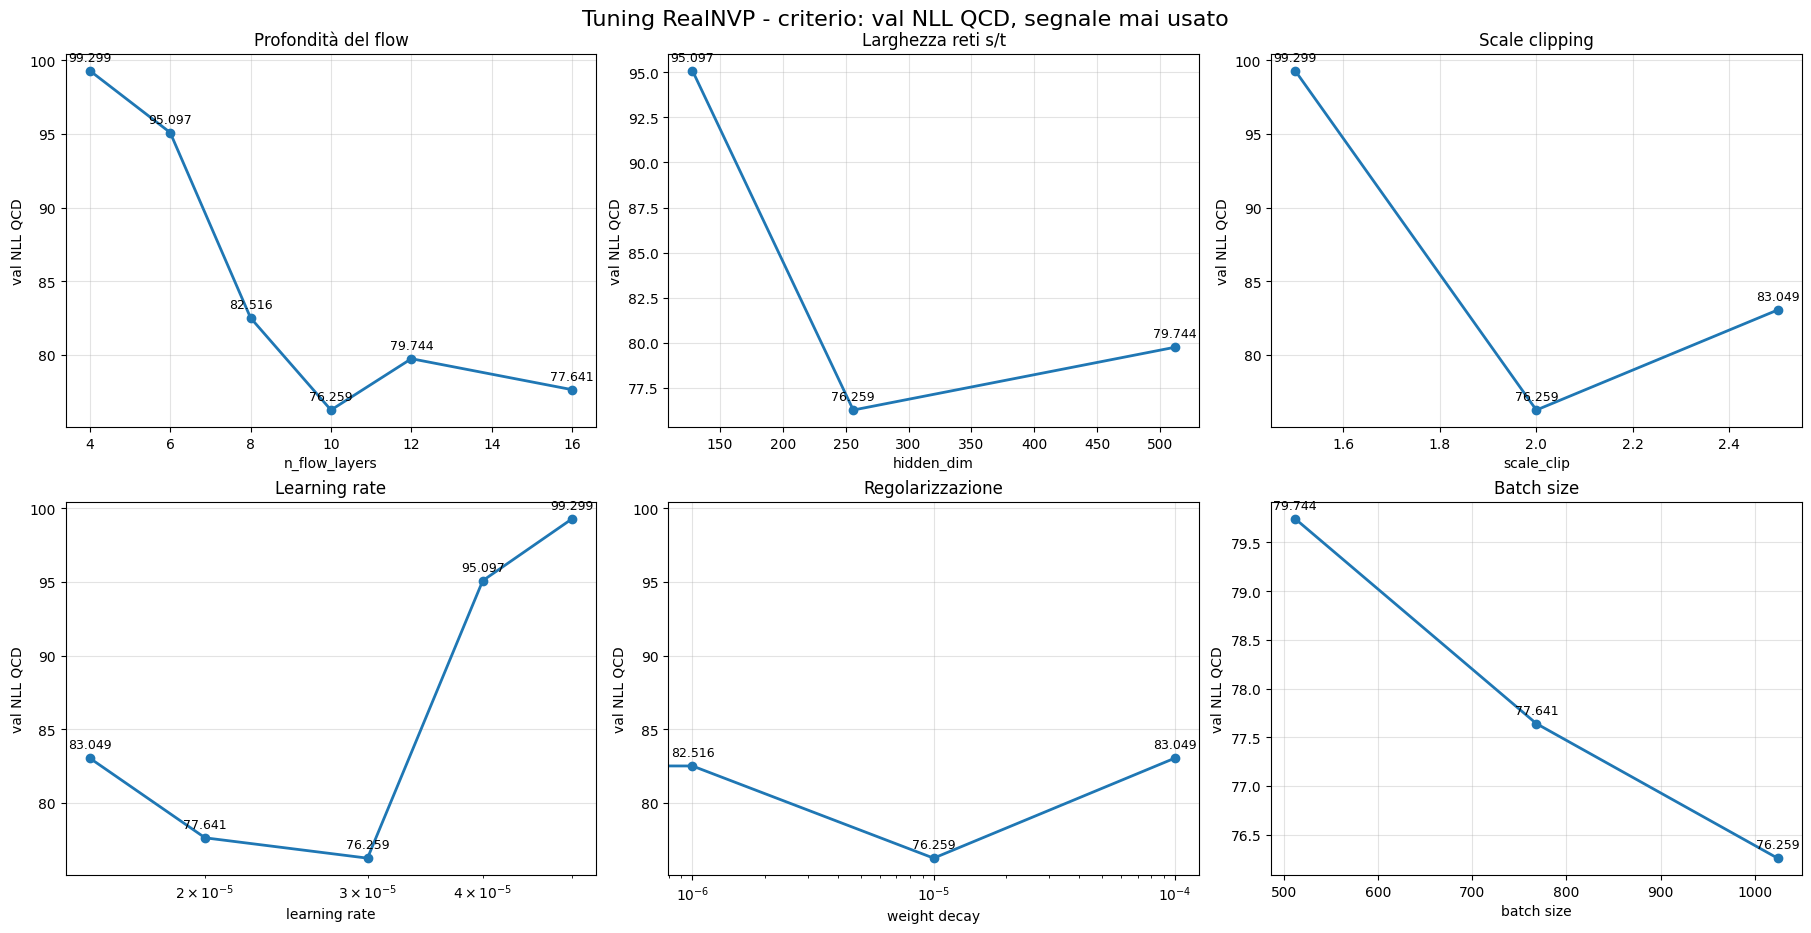

Salvato: ..\outputs\normalizing_flow\plots\realnvp_hparam_elbow_plots.png


,config_id,n_flow_layers,hidden_dim,scale_clip,lr,weight_decay,batch_size,n_params,best_epoch,train_nll,val_nll,generalization_gap,selection_score
0,4,10,256,2.0,0.000030,0.000010,1024,1813440,20,71.825035,75.235852,3.410817,76.259097
1,7,16,256,2.0,0.000020,0.000010,768,2901504,18,71.223867,76.159817,4.935949,77.640602
2,6,12,512,2.0,0.000020,0.000010,512,7496832,19,76.389489,78.969623,2.580134,79.743664
3,3,8,256,2.0,0.000030,0.000001,1024,1450752,20,77.153832,81.278952,4.125120,82.516488
4,8,16,512,2.5,0.000015,0.000100,512,9995776,8,78.699530,82.045055,3.345524,83.048712
5,5,12,256,2.5,0.000020,0.000010,768,2176128,15,84.279589,86.137859,1.858270,86.695340
6,2,6,128,2.0,0.000040,0.000001,1024,347712,20,94.613570,94.985095,0.371525,95.096552
7,1,4,128,1.5,0.000050,0.000000,1024,231808,20,98.791317,99.181659,0.390342,99.298762


In [9]:
# ============================================================
# Plot tuning RealNVP in stile "gomito"
# ============================================================

try:
    df_flow_tune = flow_tuning_results_df.copy()
except NameError:
    df_flow_tune = pd.read_csv(OUTPUT_DIR / "realnvp_hparam_tuning.csv")

Y_COL = "selection_score"
Y_LABEL = "val NLL QCD"


def best_by_param(data, param):
    return (
        data
        .groupby(param, as_index=False)[Y_COL]
        .min()
        .sort_values(param)
        .reset_index(drop=True)
    )


def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
    ax.plot(x, y, marker="o", linewidth=2)

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.3f}",
            xy=(xi, yi),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(Y_LABEL)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

    if logx:
        ax.set_xscale("log")


fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    constrained_layout=True,
)

axes = axes.flatten()

fig.suptitle(
    "Tuning RealNVP - criterio: val NLL QCD, segnale mai usato",
    fontsize=16,
    y=1.02,
)

for ax, param, xlabel, title, logx in [
    (axes[0], "n_flow_layers", "n_flow_layers", "Profondità del flow", False),
    (axes[1], "hidden_dim", "hidden_dim", "Larghezza reti s/t", False),
    (axes[2], "scale_clip", "scale_clip", "Scale clipping", False),
    (axes[3], "lr", "learning rate", "Learning rate", True),
    (axes[4], "weight_decay", "weight decay", "Regolarizzazione", True),
    (axes[5], "batch_size", "batch size", "Batch size", False),
]:
    g = best_by_param(df_flow_tune, param)
    plot_line_with_labels(
        ax,
        g[param],
        g[Y_COL],
        xlabel,
        title,
        logx=logx,
    )

out_path = PLOTS_DIR / "realnvp_hparam_elbow_plots.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Salvato:", out_path)
display(df_flow_tune.sort_values("selection_score").reset_index(drop=True))

## 8. Training: massima verosimiglianza

Allenare un flow significa fare **maximum likelihood**: rendere i jet QCD il più probabili possibile sotto il modello. Equivale a **minimizzare la NLL media** `−log p(x)` sul training QCD. Ad ogni batch: forward `x → z`, calcolo della NLL, backward, passo dell'ottimizzatore.

Dettagli pratici (gli stessi accorgimenti "stable"):
- **AdamW** con `weight_decay` e learning rate piccolo (i flow sono delicati);
- **ReduceLROnPlateau** sulla val NLL → dimezza il learning rate quando smette di migliorare;
- **`clip_grad_norm_`** e un controllo `isfinite` sulla loss → se qualcosa esplode il training si ferma con un messaggio chiaro invece di produrre `NaN`;
- **early stopping** sulla val NLL: a fine training ricarichiamo i pesi della miglior epoca.


In [10]:
# ============================================================
# Creazione modello finale usando la configurazione scelta dal tuning
# ============================================================


if "BEST_FLOW_CONFIG" in globals():
    N_FLOW_LAYERS = int(BEST_FLOW_CONFIG["n_flow_layers"])
    HIDDEN_DIM = int(BEST_FLOW_CONFIG["hidden_dim"])
    SCALE_CLIP = float(BEST_FLOW_CONFIG["scale_clip"])
    LR = float(BEST_FLOW_CONFIG["lr"])
    WEIGHT_DECAY = float(BEST_FLOW_CONFIG["weight_decay"])
    BATCH_SIZE = int(BEST_FLOW_CONFIG["batch_size"])

    N_EPOCHS = 100
    PATIENCE = 15

    print("Uso configurazione scelta dal tuning.")
else:
    N_FLOW_LAYERS = 8
    HIDDEN_DIM = 256
    SCALE_CLIP = 2.0
    LR = 3e-5
    WEIGHT_DECAY = 1e-6

    BATCH_SIZE = 1024
    N_EPOCHS = 80
    PATIENCE = 12

    print("BEST_FLOW_CONFIG non trovata: uso configurazione standard.")

# Ricreo i DataLoader finali con il batch size scelto.
train_loader = DataLoader(
    AggregateDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    AggregateDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

flow = RealNVPStable(
    dim=input_dim,
    n_layers=N_FLOW_LAYERS,
    hidden_dim=HIDDEN_DIM,
    scale_clip=SCALE_CLIP,
).to(device)

optimizer = torch.optim.AdamW(
    flow.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(flow)
print("Parameters:", sum(p.numel() for p in flow.parameters() if p.requires_grad))
print()
print("Final RealNVP config:")
print("N_FLOW_LAYERS =", N_FLOW_LAYERS)
print("HIDDEN_DIM    =", HIDDEN_DIM)
print("SCALE_CLIP    =", SCALE_CLIP)
print("LR            =", LR)
print("WEIGHT_DECAY  =", WEIGHT_DECAY)
print("BATCH_SIZE    =", BATCH_SIZE)
print("N_EPOCHS      =", N_EPOCHS)
print("PATIENCE      =", PATIENCE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Uso configurazione scelta dal tuning.
RealNVPStable(
  (layers): ModuleList(
    (0): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=256, out_features=48, bias=True)
        )
      )
      (t_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=256, out_features=48, bias=True)
        )
      )
    )
    (1): PermutationLayer()
    (2): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_feature

In [11]:
def evaluate_nll(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            nll = model.negative_log_likelihood(X_batch)
            loss = nll.mean()

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


train_history = []
val_history = []
lr_history = []

best_val = np.inf
best_epoch = -1
best_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    flow.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        nll = flow.negative_log_likelihood(X_batch)
        loss = nll.mean()

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita. Prova a ridurre LR, scale_clip o clip_value.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_nll = total_loss / max(total_items, 1)
    val_nll = evaluate_nll(flow, val_loader)

    scheduler.step(val_nll)
    current_lr = optimizer.param_groups[0]["lr"]

    train_history.append(train_nll)
    val_history.append(val_nll)
    lr_history.append(current_lr)

    improved = val_nll < best_val

    if improved:
        best_val = val_nll
        best_epoch = epoch + 1
        best_state = copy.deepcopy(flow.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train NLL={train_nll:.6f} | "
        f"val NLL={val_nll:.6f} | "
        f"best={best_val:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping.")
        break

if best_state is not None:
    flow.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val NLL={best_val:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_history) + 1),
    "train_nll": train_history,
    "val_nll": val_history,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "realnvp_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "realnvp_training_history.csv")

Epoch 001/100 | train NLL=141.321963 | val NLL=130.381186 | best=130.381186 @ 1 | lr=3.00e-05
Epoch 002/100 | train NLL=121.607377 | val NLL=112.794145 | best=112.794145 @ 2 | lr=3.00e-05
Epoch 003/100 | train NLL=106.137841 | val NLL=99.278249 | best=99.278249 @ 3 | lr=3.00e-05
Epoch 004/100 | train NLL=110.063436 | val NLL=98.403736 | best=98.403736 @ 4 | lr=3.00e-05
Epoch 005/100 | train NLL=134.144006 | val NLL=94.690714 | best=94.690714 @ 5 | lr=3.00e-05
Epoch 006/100 | train NLL=103.482117 | val NLL=93.050247 | best=93.050247 @ 6 | lr=3.00e-05
Epoch 007/100 | train NLL=161.468361 | val NLL=92.042760 | best=92.042760 @ 7 | lr=3.00e-05
Epoch 008/100 | train NLL=105.818658 | val NLL=88.741875 | best=88.741875 @ 8 | lr=3.00e-05
Epoch 009/100 | train NLL=98.310864 | val NLL=102.419151 | best=88.741875 @ 8 | lr=3.00e-05
Epoch 010/100 | train NLL=120.108419 | val NLL=97.465864 | best=88.741875 @ 8 | lr=3.00e-05
Epoch 011/100 | train NLL=96.044429 | val NLL=89.638458 | best=88.741875 @ 8

## 9. Training plots

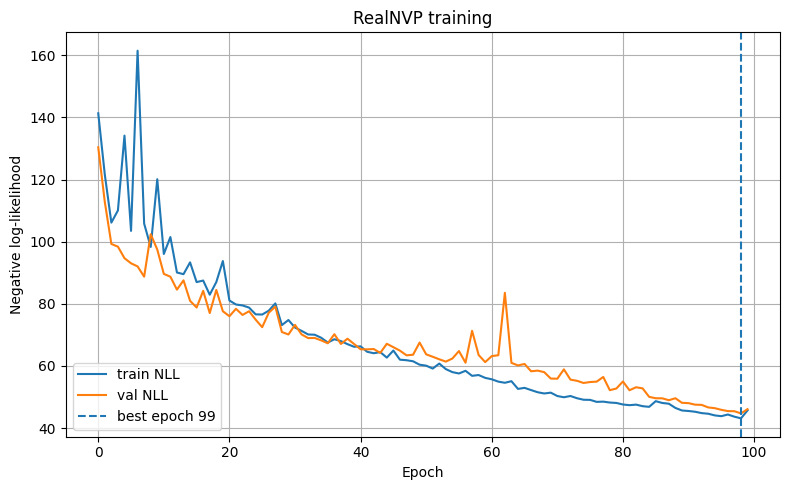

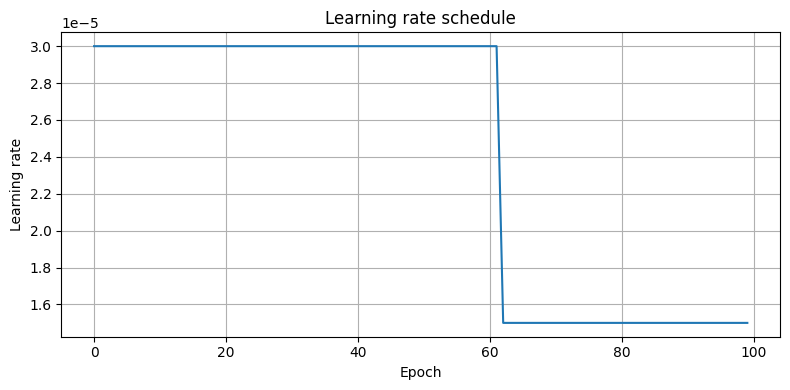

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="train NLL")
plt.plot(val_history, label="val NLL")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.title("RealNVP training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_lr_schedule.png", dpi=200)
plt.show()

## 10. Anomaly score: la NLL

Per ogni jet calcoliamo `NLL = −log p(x)` (su train, val, test QCD e segnale). È direttamente il nostro anomaly score: **alto = bassa probabilità = anomalo**. Le statistiche stampate (media, mediana, quantili) servono da controllo: ci aspettiamo che le tre distribuzioni QCD (train/val/test) siano simili tra loro e che il **segnale EJ sia spostato verso NLL più alte**.


In [13]:
def compute_flow_scores(model, X, batch_size=4096):
    loader = DataLoader(
        AggregateDataset(X),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores = []
    logps = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            logp = model.log_prob(X_batch)
            nll = -logp

            scores.append(nll.cpu().numpy())
            logps.append(logp.cpu().numpy())

    return np.concatenate(scores), np.concatenate(logps)


scores_train, logp_train = compute_flow_scores(flow, X_train)
scores_val, logp_val = compute_flow_scores(flow, X_val)
scores_bkg_test, logp_bkg_test = compute_flow_scores(flow, X_bkg_test)
scores_sig, logp_sig = compute_flow_scores(flow, X_sig)


def print_summary(name, scores):
    print("\n", name)
    print("mean:", float(np.mean(scores)))
    print("std:", float(np.std(scores)))
    print("median:", float(np.median(scores)))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))


print_summary("train NLL", scores_train)
print_summary("val NLL", scores_val)
print_summary("bkg_test NLL", scores_bkg_test)
print_summary("signal NLL", scores_sig)


 train NLL
mean: 42.851951599121094
std: 31.142658233642578
median: 39.35746765136719
quantiles: [   2.87522125   16.78606827   22.79987297   32.01224709   39.35746765
   48.32876015   70.76429558  101.50576454  357.71368634 2361.30053711]

 val NLL
mean: 44.74017333984375
std: 166.5678253173828
median: 39.408721923828125
quantiles: [3.01449585e+00 1.70234104e+01 2.29412777e+01 3.21281834e+01
 3.94087219e+01 4.86781006e+01 7.16002113e+01 1.07014542e+02
 5.54646507e+02 2.29429609e+04]

 bkg_test NLL
mean: 43.78773880004883
std: 70.92947387695312
median: 39.41747283935547
quantiles: [3.52603912e+00 1.72188625e+01 2.30783958e+01 3.20909786e+01
 3.94174728e+01 4.87012177e+01 7.18647911e+01 1.06697083e+02
 3.78513067e+02 8.13640527e+03]

 signal NLL
mean: 50871.08984375
std: 6560073.0
median: 73.68871307373047
quantiles: [1.44651413e+01 2.80425320e+01 3.67032238e+01 5.48938961e+01
 7.36887131e+01 1.02857883e+02 1.94086016e+02 8.26700164e+02
 2.38149709e+06 1.29187584e+09]


## 11. Metriche: AUC, efficienza, controlli sul fondo

- **`orient_scores`** — garantisce che lo score sia orientato "alto = più simile al segnale", invertendolo se per caso l'AUC risultasse < 0.5.
- **AUC** — se prendi a caso un EJ e un QCD, è la probabilità che il modello dia score più alto all'EJ (1 = perfetto, 0.5 = caso).
- **Efficienza a mistag fissato** — a una percentuale fissa di QCD scambiati per segnale (30%…0.1%), quanti EJ catturiamo? È la lettura operativa.
- **Controlli sul fondo (`bg_vs_bg_auc`)** — confrontiamo train/val/test QCD tra loro: dovrebbero essere indistinguibili (**AUC ≈ 0.5**). Se così non fosse, parte della "anomalia" sarebbe solo differenza tra fondi, non vero segnale. Qui il test è held-out, quindi è un controllo onesto.


In [14]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="RealNVP"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": "NLL",
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


eval_main = evaluate_scores(scores_bkg_test, scores_sig, model_name="RealNVP")

print("AUC:", eval_main["auc"])
print("AUC inverted:", eval_main["auc_inverted"])
print("Best AUC:", eval_main["best_auc"])
print("Flipped:", eval_main["flipped"])

display(eval_main["eff_table"])


def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train, scores_bkg_test, "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val, scores_bkg_test, "val QCD", "test QCD"),
])

display(bg_checks)

AUC: 0.87092954625
AUC inverted: 0.12907045374999998
Best AUC: 0.87092954625
Flipped: False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,RealNVP,NLL,0.87093,0.87093,0.12907,False,0.300,0.300,0.862800,46.203129
1,RealNVP,NLL,0.87093,0.87093,0.12907,False,0.100,0.100,0.668475,60.895123
2,RealNVP,NLL,0.87093,0.87093,0.12907,False,0.050,0.050,0.521450,71.864792
3,RealNVP,NLL,0.87093,0.87093,0.12907,False,0.010,0.010,0.228650,106.697083
4,RealNVP,NLL,0.87093,0.87093,0.12907,False,0.001,0.001,0.017400,378.513062


,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.503281,0.496719,0.503281
1,train QCD vs test QCD,0.502983,0.497017,0.502983
2,val QCD vs test QCD,0.499679,0.500321,0.500321


## 12. Grafici finali

Quattro figure:
1. **ROC** — TPR (efficienza EJ) vs FPR (mistag QCD), con l'AUC;
2. **Distribuzione degli score** (asse y logaritmico) — fondo vs segnale: si vede la coda del segnale a NLL alte;
3. **Efficienza vs mistag** (asse x logaritmico) — utile per leggere il regime a basso mistag, quello che conta in fisica;
4. **Consistenza del fondo** — le NLL di train/val/test QCD sovrapposte (devono coincidere) e il segnale spostato a destra.


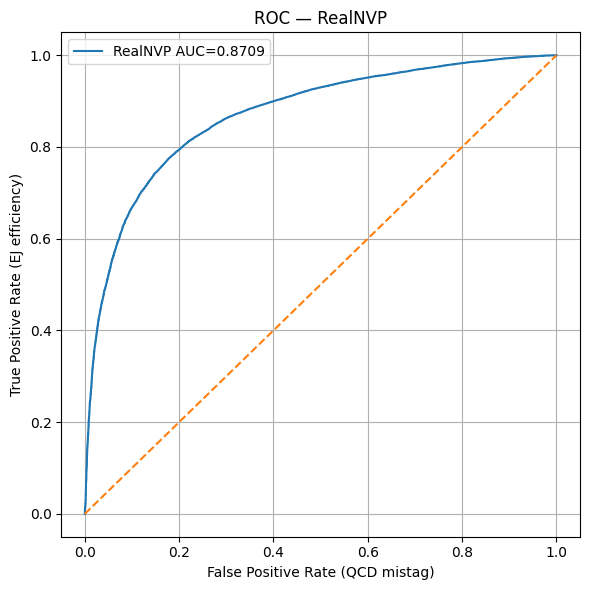

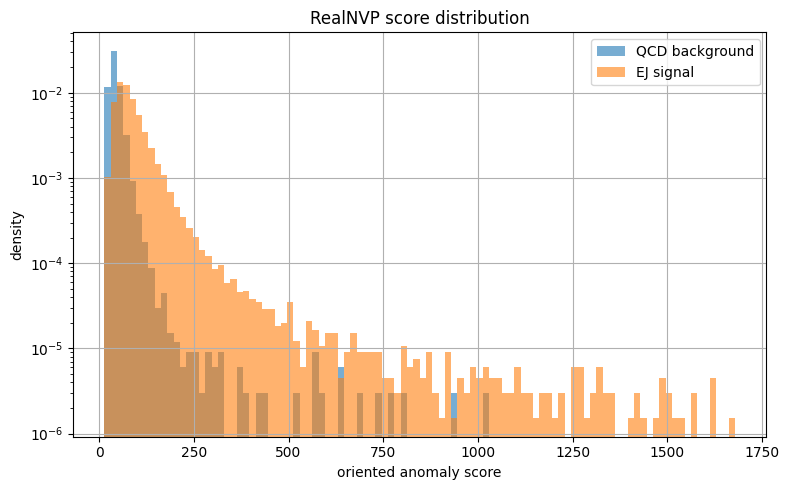

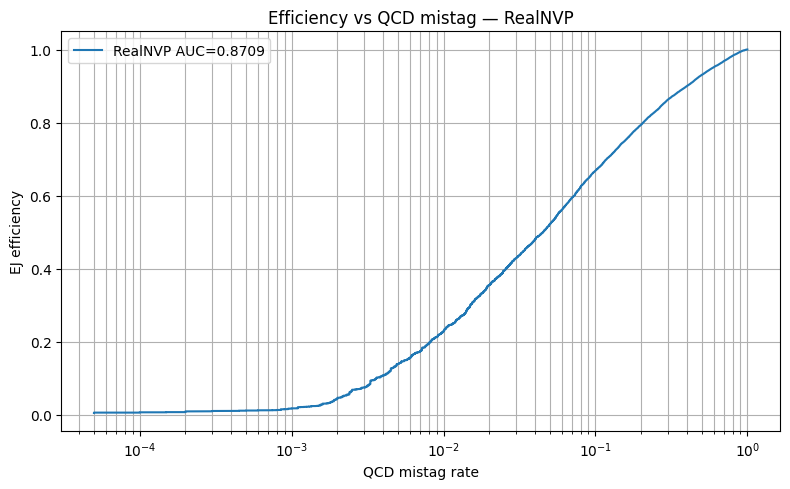

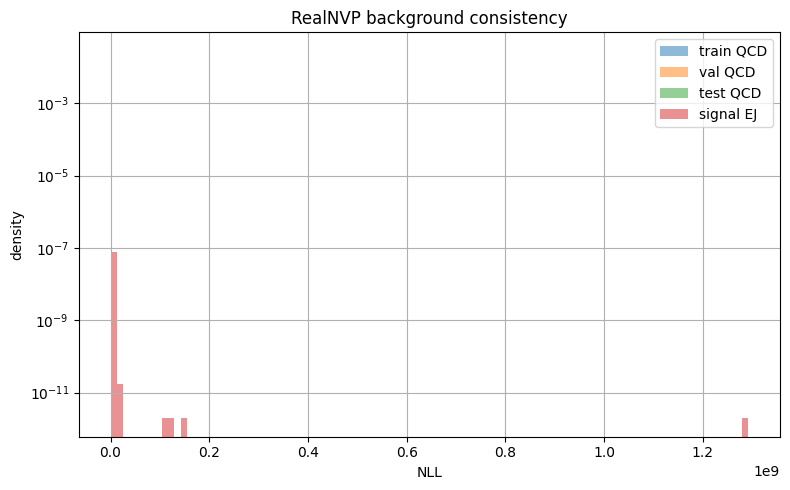

In [15]:
bg_o = eval_main["bg_oriented"]
sig_o = eval_main["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(eval_main["fpr"], eval_main["tpr"], label=f"RealNVP AUC={eval_main['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — RealNVP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented anomaly score")
plt.ylabel("density")
plt.title("RealNVP score distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_score_distribution.png", dpi=200)
plt.show()

fpr = eval_main["fpr"]
tpr = eval_main["tpr"]
mask = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask], tpr[mask], label=f"RealNVP AUC={eval_main['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — RealNVP")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_efficiency_vs_mistag.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val, bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig, bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel("NLL")
plt.ylabel("density")
plt.title("RealNVP background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_background_consistency.png", dpi=200)
plt.show()

## 14. Salvataggio finale

In [16]:
results_summary = {
    "model": "RealNVP",
    "score": "NLL",
    "auc": float(eval_main["auc"]),
    "auc_inverted": float(eval_main["auc_inverted"]),
    "best_auc": float(eval_main["best_auc"]),
    "flipped": bool(eval_main["flipped"]),
    "input_dim": int(input_dim),
    "n_flow_layers": int(N_FLOW_LAYERS),
    "hidden_dim": int(HIDDEN_DIM),
    "scale_clip": float(SCALE_CLIP),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "hparam_tuning_used": bool("flow_tuning_results_df" in globals()),
    "hparam_selection_score": float(BEST_FLOW_CONFIG.get("selection_score", np.nan)) if "BEST_FLOW_CONFIG" in globals() else float("nan"),
    "best_epoch": int(best_epoch),
    "best_val_nll": float(best_val),
    "clip_value": float(CLIP_VALUE),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "realnvp_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "aggregate_feature_names": aggregate_feature_names,
            "processed_path": str(PROCESSED_PATH),
            "scaler": scaler.state_dict(),
        },
        f,
        indent=2,
    )

eval_main["eff_table"].to_csv(OUTPUT_DIR / "realnvp_results.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "realnvp_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": flow.state_dict(),
        "config": results_summary,
        "aggregate_feature_names": aggregate_feature_names,
        "scaler": scaler.state_dict(),
        "train_history": train_history,
        "val_history": val_history,
    },
    OUTPUT_DIR / "realnvp_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "realnvp_scores.npz",
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    logp_train=logp_train,
    logp_val=logp_val,
    logp_bkg_test=logp_bkg_test,
    logp_sig=logp_sig,
    bg_oriented=eval_main["bg_oriented"],
    sig_oriented=eval_main["sig_oriented"],
    fpr=eval_main["fpr"],
    tpr=eval_main["tpr"],
    thresholds=eval_main["thresholds"],
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc=np.array(eval_main["auc"], dtype=np.float32),
    auc_inverted=np.array(eval_main["auc_inverted"], dtype=np.float32),
    best_auc=np.array(eval_main["best_auc"], dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "realnvp_model.pt")
print(OUTPUT_DIR / "realnvp_scores.npz")
print(OUTPUT_DIR / "realnvp_results.csv")
print(OUTPUT_DIR / "realnvp_background_checks.csv")
print(OUTPUT_DIR / "realnvp_config.json")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\normalizing_flow\realnvp_model.pt
..\outputs\normalizing_flow\realnvp_scores.npz
..\outputs\normalizing_flow\realnvp_results.csv
..\outputs\normalizing_flow\realnvp_background_checks.csv
..\outputs\normalizing_flow\realnvp_config.json
plots: ..\outputs\normalizing_flow\plots
